# Лабораторная работа №2: Предобработка данных

Цель лабораторной работы: изучение способов предварительной обработки данных для дальнейшего формирования моделей.

In [175]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

## 1. Загрузка данных

В качестве набора данных для работы выберем датасет Titanic-Dataset. Он подходит для этой лабораторной работы, т.к. содержит как числовые и категориальные признаки, а также имеет пропуски в данных.

In [183]:
data = pd.read_csv('Titanic-Dataset.csv', sep=",")

## 2. Первичный анализ данных

Прежде чем приступать к обработке, посмотрим на размер датасета, типы данных в колонках и количество пропусков.

In [185]:
data.shape

(891, 12)

In [187]:
# типы колонок
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [189]:

# проверим есть ли пропущенные значения
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Пропуски есть в трех колонках:

1) Age: 177 пропусков (числовая)
2) Cabin: 687 пропусков (категориальная)
3) Embarked: 2 пропуска (категориальная)

In [191]:

# Первые 5 строк датасета
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [45]:

hdata.shape

(891, 12)

In [193]:

total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 891


## 3. Обработка пропусков в данных

### Простые стратегии удаления

Самый простой способ — удалить колонки или строки с пропусками. Однако это может привести к значительной потере данных.

Важно: Эти методы применяются для демонстрации, но мы не будем использовать их как основные.

In [195]:

#Обработка пропусков в данных
#Простые стратегии - удаление или заполнение нулями

# Удаление колонок, содержащих пустые значения
data_new_1 = data.dropna(axis=1, how='any')
(data.shape, data_new_1.shape)

((891, 12), (891, 9))

In [197]:

# Удаление строк, содержащих пустые значения
data_new_2 = data.dropna(axis=0, how='any')
(data.shape, data_new_2.shape)

((891, 12), (183, 12))

Удаление строк и колонок неэффективно. 

В случае с удалением строк вместо 891 строки у нас осталось только 183. Мы потеряли более 80% данных, что неприемлемо.

In [199]:

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [201]:
# Заполнение всех пропущенных значений нулями
# В данном случае это некорректно, так как нулями заполняются в том числе категориальные колонки
data_new_3 = data.fillna(0)
data_new_3.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,0,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,0,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,0,S


### Обработка пропусков в числовых данных (Imputation)

Цель — найти числовые колонки с пропусками и заполнить их осмысленными значениями.

In [203]:

#"Внедрение значений" - импьютация (imputation)
#Обработка пропусков в числовых данных
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))


Колонка Age. Тип данных float64. Количество пустых значений 177, 19.87%.


Единственная числовая колонка с пропусками — Age.

Посмотрим на распределение возраста, чтобы выбрать лучшую стратегию заполнения.

In [205]:

# Фильтр по колонкам с пропущенными значениями
data_num = data[num_cols]
data_num


,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


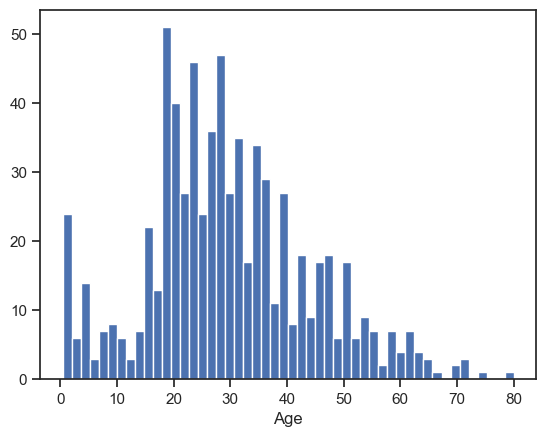

In [207]:
# Гистограмма по признакам
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

Распределение возраста похоже на нормальное, поэтому для заполнения пропусков хорошо подойдет среднее или медианное значение.

Теперь применим разные стратегии заполнения с использованием SimpleImputer из библиотеки sklearn.

In [339]:
data_num_Age = data_num[['Age']]
data_num_Age.head()

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


In [215]:

from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [341]:
# Фильтр для проверки заполнения пустых значений
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_Age)
mask_missing_values_only

array([[False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [221]:
strategies=['mean', 'median', 'most_frequent']

In [343]:
def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_Age)
    return data_num_imp[mask_missing_values_only]

Применим каждую стратегию и посмотрим, какие значения были использованы для заполнения.

In [225]:

strategies[0], test_num_impute(strategies[0])

('mean',
 array([29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911765, 29.69911765, 29.69911765,
        29.69911765, 29.69911765, 29.69911

Средний возраст = 29.7 лет. Все пропуски заполнены этим значением.

In [227]:

strategies[1], test_num_impute(strategies[1])

('median',
 array([28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28., 28.,
        28., 28., 28., 28., 28., 28., 28

Медианный возраст = 28 лет. Все пропуски заполнены этим значением.

In [229]:
strategies[2], test_num_impute(strategies[2])

('most_frequent',
 array([24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 

Самый частый возраст = 24 года. Все пропуски заполнены этим значением.

Вывод: Для числовой колонки Age мы можем выбрать любую из стратегий, но чаще всего используют медиану, так как она устойчива к выбросам. В данном случае все стратегии дают схожие результаты.

In [231]:
# Более сложная функция, которая позволяет задавать колонку и вид импьютации
def test_num_impute_col(dataset, column, strategy_param):
    temp_data = dataset[[column]]
    
    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)
    
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(temp_data)
    
    filled_data = data_num_imp[mask_missing_values_only]
    
    return column, strategy_param, filled_data.size, filled_data[0], filled_data[filled_data.size-1]

In [237]:

data[['Age']].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [239]:
test_num_impute_col(data, 'Age', strategies[0])

('Age', 'mean', 177, 29.69911764705882, 29.69911764705882)

In [241]:
test_num_impute_col(data, 'Age', strategies[1])

('Age', 'median', 177, 28.0, 28.0)

In [243]:
test_num_impute_col(data, 'Age', strategies[2])

('Age', 'most_frequent', 177, 24.0, 24.0)

### Обработка пропусков в категориальных данных

Найдем категориальные колонки с пропусками.

In [245]:
# Выберем категориальные колонки с пропущенными значениями
# Цикл по колонкам датасета
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))


Колонка Cabin. Тип данных object. Количество пустых значений 687, 77.1%.
Колонка Embarked. Тип данных object. Количество пустых значений 2, 0.22%.


Категориальные колонки с пропусками: Cabin (очень много пропусков) и Embarked (всего 2 пропуска).

Для демонстрации обработаем колонку Embarked. Поскольку пропусков всего 2, мы можем просто заменить их на самое частое значение ('S').

In [251]:
cat_temp_data = data[['Embarked']]
cat_temp_data.head()

,Embarked
0,S
1,C
2,S
3,S
4,S


In [253]:
cat_temp_data['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [255]:
cat_temp_data[cat_temp_data['Embarked'].isnull()].shape

(2, 1)

Применим импьютацию с использованием самой частой категории.

In [257]:
# Импьютация наиболее частыми значениями
imp2 = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data_imp2 = imp2.fit_transform(cat_temp_data)
data_imp2

array([['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['Q'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['Q'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['Q'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['Q'],
       ['S'],
       ['C'],
       ['C'],
       ['Q'],
       ['S'],
       ['C'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['C'],
       ['C'],
       ['Q'],
       ['S'],
       ['Q'],
       ['Q'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
      

In [259]:
# Пустые значения отсутствуют
np.unique(data_imp2)

array(['C', 'Q', 'S'], dtype=object)

In [261]:
# Импьютация константой
imp3 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_imp3 = imp3.fit_transform(cat_temp_data)
data_imp3

array([['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['Q'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['Q'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['Q'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['Q'],
       ['S'],
       ['C'],
       ['C'],
       ['Q'],
       ['S'],
       ['C'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['C'],
       ['C'],
       ['Q'],
       ['S'],
       ['Q'],
       ['Q'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['C'],
       ['NA'],
       ['S'],
       ['S'],
       ['C'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
     

In [263]:
np.unique(data_imp3)

array(['C', 'NA', 'Q', 'S'], dtype=object)

In [265]:
data_imp3[data_imp3=='NA'].size

2

## Кодирование категориальных признаков

Большинство алгоритмов машинного обучения работают только с числовыми данными. Поэтому категориальные признаки нужно преобразовать в числовой формат.

### Преобразование в числовые с помощью LabelEncoder

LabelEncoder присваивает каждой категории уникальный целочисленный код

In [267]:
#Преобразование категориальных признаков в числовые

cat_enc = pd.DataFrame({'c1':data_imp2.T[0]})
cat_enc

,c1
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


In [269]:
from sklearn.preprocessing import LabelEncoder

In [271]:
cat_enc['c1'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [273]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(cat_enc['c1'])

In [275]:
# Наименования категорий в соответствии с порядковыми номерами

# Свойство называется classes, потому что предполагается что мы решаем 
# задачу классификации и каждое значение категории соответствует 
# какому-либо классу целевого признака

le.classes_

array(['C', 'Q', 'S'], dtype=object)

In [277]:
cat_enc_le

array([2, 0, 2, 2, 2, 1, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 1, 2, 2, 0, 2, 2,
       1, 2, 2, 2, 0, 2, 1, 2, 0, 0, 1, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 0,
       1, 2, 1, 1, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 2, 0, 0,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,
       2, 0, 2, 2, 0, 2, 1, 2, 0, 2, 2, 2, 0, 2, 2, 0, 1, 2, 0, 2, 0, 2,
       2, 2, 2, 0, 2, 2, 2, 0, 0, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 0, 2,
       2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 0, 0, 1, 2,
       1, 2, 2, 2, 2, 0, 2, 2, 2, 0, 1, 0, 2, 2, 2, 2, 1, 0, 2, 2, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1,
       2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 0, 2, 1, 2, 2, 2,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 0,
       2, 2, 2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 2, 0, 1,

In [279]:
np.unique(cat_enc_le)

array([0, 1, 2])

In [283]:
# В этом примере видно, что перед кодированием 
# уникальные значения признака сортируются в лексикографиеском порядке
le.inverse_transform([0, 1, 2])

array(['C', 'Q', 'S'], dtype=object)

Категории отсортированы в алфавитном порядке: 'C' → 0, 'Q' → 1, 'S' → 2.

Недостаток: LabelEncoder может внести ложный порядок (например, 'C' < 'Q' < 'S'), что неверно для номинативных признаков.

### Кодирование нескольких признаков с помощью OrdinalEncoder

OrdinalEncoder работает аналогично, но может кодировать сразу несколько колонок.

In [285]:
#Использование OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

In [293]:
data_oe = data[['Cabin', 'Sex', 'Embarked']]
data_oe.head()

,Cabin,Sex,Embarked
0,NaN,male,S
1,C85,female,C
2,NaN,female,S
3,C123,female,S
4,NaN,male,S


Сначала заполним пропуски в Cabin и Embarked константой 'NA'.

In [295]:
imp4 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_oe_filled = imp4.fit_transform(data_oe)
data_oe_filled

array([['NA', 'male', 'S'],
       ['C85', 'female', 'C'],
       ['NA', 'female', 'S'],
       ...,
       ['NA', 'female', 'S'],
       ['C148', 'male', 'C'],
       ['NA', 'male', 'Q']], dtype=object)

In [297]:
oe = OrdinalEncoder()
cat_enc_oe = oe.fit_transform(data_oe_filled)
cat_enc_oe

array([[146.,   1.,   3.],
       [ 81.,   0.,   0.],
       [146.,   0.,   3.],
       ...,
       [146.,   0.,   3.],
       [ 60.,   1.,   0.],
       [146.,   1.,   2.]])

In [299]:
# Уникальные значения 1 признака
np.unique(cat_enc_oe[:, 0])

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144., 145., 146., 147.])

In [301]:
# Уникальные значения 2 признака
np.unique(cat_enc_oe[:, 1])

array([0., 1.])

In [303]:
# Уникальные значения 3 признака
np.unique(cat_enc_oe[:, 2])

array([0., 1., 2., 3.])

In [305]:
# Наименования категорий в соответствии с порядковыми номерами
oe.categories_

[array(['A10', 'A14', 'A16', 'A19', 'A20', 'A23', 'A24', 'A26', 'A31',
        'A32', 'A34', 'A36', 'A5', 'A6', 'A7', 'B101', 'B102', 'B18',
        'B19', 'B20', 'B22', 'B28', 'B3', 'B30', 'B35', 'B37', 'B38',
        'B39', 'B4', 'B41', 'B42', 'B49', 'B5', 'B50', 'B51 B53 B55',
        'B57 B59 B63 B66', 'B58 B60', 'B69', 'B71', 'B73', 'B77', 'B78',
        'B79', 'B80', 'B82 B84', 'B86', 'B94', 'B96 B98', 'C101', 'C103',
        'C104', 'C106', 'C110', 'C111', 'C118', 'C123', 'C124', 'C125',
        'C126', 'C128', 'C148', 'C2', 'C22 C26', 'C23 C25 C27', 'C30',
        'C32', 'C45', 'C46', 'C47', 'C49', 'C50', 'C52', 'C54', 'C62 C64',
        'C65', 'C68', 'C7', 'C70', 'C78', 'C82', 'C83', 'C85', 'C86',
        'C87', 'C90', 'C91', 'C92', 'C93', 'C95', 'C99', 'D', 'D10 D12',
        'D11', 'D15', 'D17', 'D19', 'D20', 'D21', 'D26', 'D28', 'D30',
        'D33', 'D35', 'D36', 'D37', 'D45', 'D46', 'D47', 'D48', 'D49',
        'D50', 'D56', 'D6', 'D7', 'D9', 'E10', 'E101', 'E12', 'E121',

In [307]:
# Обратное преобразование
oe.inverse_transform(cat_enc_oe)

array([['NA', 'male', 'S'],
       ['C85', 'female', 'C'],
       ['NA', 'female', 'S'],
       ...,
       ['NA', 'female', 'S'],
       ['C148', 'male', 'C'],
       ['NA', 'male', 'Q']], dtype=object)

### One-Hot Encoding (Создание фиктивных переменных)

Это наиболее правильный способ кодирования номинативных категориальных признаков. Он создает новые бинарные колонки для каждой категории.

In [309]:
#Кодирование категорий наборами бинарных значений - one-hot encoding
from sklearn.preprocessing import OneHotEncoder


Закодируем колонку Embarked с помощью One-Hot Encoding.

In [311]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(cat_enc[['c1']])

In [313]:
cat_enc.shape

(891, 1)

In [315]:
cat_enc_ohe.shape

(891, 3)

Результат — это разреженная матрица. Посмотрим на первые 10 строк в обычном (плотном) формате.

In [317]:
cat_enc_ohe

<891x3 sparse matrix of type '<class 'numpy.float64'>'
	with 891 stored elements in Compressed Sparse Row format>

In [319]:
cat_enc_ohe.todense()[0:10]

matrix([[0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [1., 0., 0.]])

In [321]:
cat_enc.head(10)

,c1
0,S
1,C
2,S
3,S
4,S
5,Q
6,S
7,S
8,S
9,C


Мы видим, что каждой категории (C, Q, S) соответствует своя колонка.

Быстрый способ в Pandas: pd.get_dummies

In [323]:
#Pandas get_dummies - быстрый вариант one-hot кодирования
pd.get_dummies(cat_enc).head()

,c1_C,c1_Q,c1_S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True


In [325]:
pd.get_dummies(cat_temp_data, dummy_na=True).head()

,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,False,False,True,False
1,True,False,False,False
2,False,False,True,False
3,False,False,True,False
4,False,False,True,False


## Масштабирование данных

Масштабирование (нормализация или стандартизация) приводит числовые признаки к одному масштабу, что важно для многих алгоритмов (например, градиентный спуск, SVM, PCA).

In [327]:
#Масштабирование данных
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

### MinMaxScaler (Нормализация)

Приводит данные к диапазону [0, 1].

In [329]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['Age']])

Посмотрим на распределение после масштабирования.

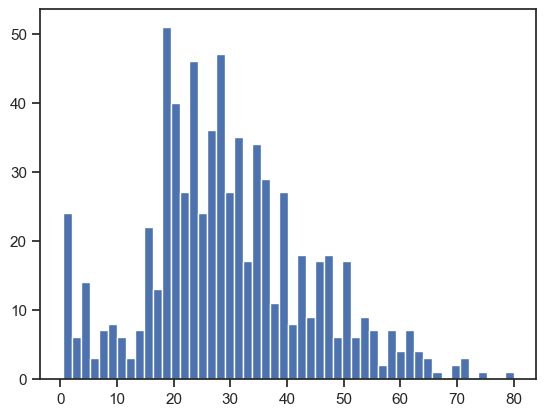

In [331]:
plt.hist(data['Age'], 50)
plt.show()

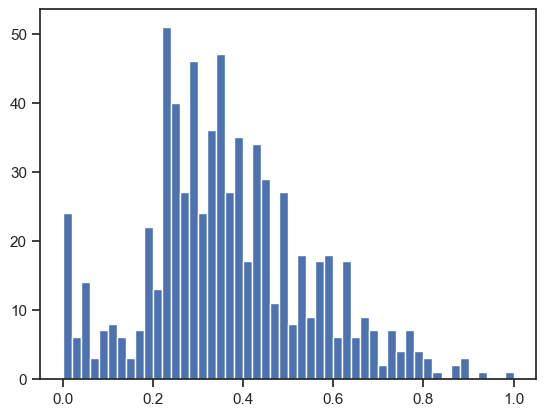

In [333]:
plt.hist(sc1_data, 50)
plt.show()

Распределение сохранилось, но значения теперь находятся в диапазоне от 0 до 1.

### StandardScaler (Стандартизация)

Приводит данные к распределению со средним = 0 и стандартным отклонением = 1 (Z-оценка).

In [335]:
#Масштабирование данных на основе Z-оценки - StandardScaler
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['Age']])

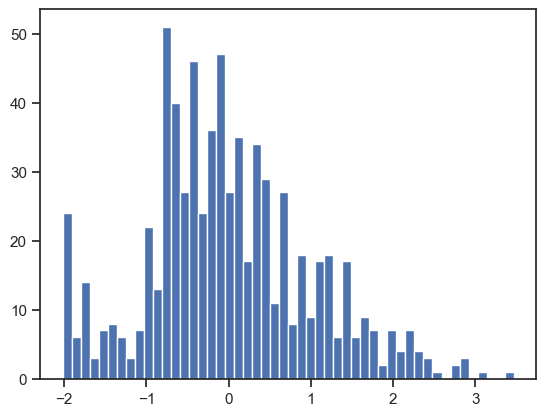

In [337]:
plt.hist(sc2_data, 50)
plt.show()

Распределение также сохранилось, но теперь среднее значение близко к 0, а стандартное отклонение — к 1.

## Заключение

В ходе выполнения лабораторной работы мы:

1) Провели первичный анализ данных Titanic.
2) Рассмотрели и применили различные методы обработки пропусков:
- Удаление строк и колонок.
- Заполнение числовых пропусков средним, медианным и модальным значениями с использованием SimpleImputer.
- Заполнение категориальных пропусков модальным значением и константой.
3) Изучили способы кодирования категориальных признаков:
- LabelEncoder и OrdinalEncoder для порядкового кодирования.
- One-Hot Encoding (через OneHotEncoder и pd.get_dummies).
4) Применили масштабирование числовых данных с помощью MinMaxScaler и StandardScaler.

Все эти этапы являются критически важными при подготовке данных для решения задач машинного обучения.